# Coursera Online Courses Analysis

# About the Project


The goal of this project is identifying patterns in the Coursera Online Courses market.

Based on the available information in the dataset I'm able to raise the following hypotheses:

1.   Top 10% percent of organizations (by student enrollment) make up 50% or larger share of the market.
2.   Course student enrollment and course ratings are correlated. Expected correlation value - 0.25 or higher.
3.   Courses with the lowest difficulty make up 50% or larger share of the market, while courses with the highest difficulty make up 10% or lower share of the market.
4.   Courses with the lowest-skill certificate types make up 50% of larger share of the market, while courses with higher-skill certificate types make up 10% or lower share of the market.





# Agenda


1.   Initial inspection of data.
2.   Data cleaning and identifying outliers.
3.   Exploration of the data and market pattern identification
4.   Conclusions and recommendations for further analysis



# 1. Overview of the Dataset

### 1.1. Importing modules

In [715]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

### 1.2. Loading data into dataframe

In [716]:
df = pd.read_csv("coursea_data.csv")
df.head()

,Unnamed: 0,course_title,course_organization,course_Certificate_type,course_rating,course_difficulty,course_students_enrolled
0,134,(ISC)² Systems Security Certified Practitioner...,(ISC)²,SPECIALIZATION,4.7,Beginner,5.3k
1,743,A Crash Course in Causality: Inferring Causal...,University of Pennsylvania,COURSE,4.7,Intermediate,17k
2,874,A Crash Course in Data Science,Johns Hopkins University,COURSE,4.5,Mixed,130k
3,413,A Law Student's Toolkit,Yale University,COURSE,4.7,Mixed,91k
4,635,A Life of Happiness and Fulfillment,Indian School of Business,COURSE,4.8,Mixed,320k


### 1.3. Data Types

In [717]:
df.dtypes

,0
Unnamed: 0,int64
course_title,object
course_organization,object
course_Certificate_type,object
course_rating,float64
course_difficulty,object
course_students_enrolled,object


### 1.4. Summary statistics

In [718]:
df.describe()

,Unnamed: 0,course_rating
count,891.000000,891.000000
mean,445.000000,4.677329
std,257.353842,0.162225
min,0.000000,3.300000
25%,222.500000,4.600000
50%,445.000000,4.700000
75%,667.500000,4.800000
max,890.000000,5.000000




"Unnamed: 0" column seems to be the index of original dataset, because min, max and all the quartiles match the column's row. Because it's redundant, it need to be dropped.



In [719]:
df.describe(include=["object"])

,course_title,course_organization,course_Certificate_type,course_difficulty,course_students_enrolled
count,891,891,891,891,891
unique,888,154,3,4,205
top,Developing Your Musicianship,University of Pennsylvania,COURSE,Beginner,120k
freq,2,59,582,487,22


"Course_students_enrolled" column is an object and needs to be converted to an integer.

# 2. Data Cleaning

### 2.1. Checking for null values

In [720]:
df.isna().any()

,0
Unnamed: 0,False
course_title,False
course_organization,False
course_Certificate_type,False
course_rating,False
course_difficulty,False
course_students_enrolled,False


### 2.2. Checking for duplicate data

In [721]:
df.duplicated().any()

np.False_

### 2.3. Dropping redundant column

In [722]:
df = df.drop(columns=["Unnamed: 0"])
df.head()

,course_title,course_organization,course_Certificate_type,course_rating,course_difficulty,course_students_enrolled
0,(ISC)² Systems Security Certified Practitioner...,(ISC)²,SPECIALIZATION,4.7,Beginner,5.3k
1,A Crash Course in Causality: Inferring Causal...,University of Pennsylvania,COURSE,4.7,Intermediate,17k
2,A Crash Course in Data Science,Johns Hopkins University,COURSE,4.5,Mixed,130k
3,A Law Student's Toolkit,Yale University,COURSE,4.7,Mixed,91k
4,A Life of Happiness and Fulfillment,Indian School of Business,COURSE,4.8,Mixed,320k


### 2.4. Re-naming the column

In [723]:
df = df.rename(columns={"course_Certificate_type": "course_certificate_type"})
df.head()

,course_title,course_organization,course_certificate_type,course_rating,course_difficulty,course_students_enrolled
0,(ISC)² Systems Security Certified Practitioner...,(ISC)²,SPECIALIZATION,4.7,Beginner,5.3k
1,A Crash Course in Causality: Inferring Causal...,University of Pennsylvania,COURSE,4.7,Intermediate,17k
2,A Crash Course in Data Science,Johns Hopkins University,COURSE,4.5,Mixed,130k
3,A Law Student's Toolkit,Yale University,COURSE,4.7,Mixed,91k
4,A Life of Happiness and Fulfillment,Indian School of Business,COURSE,4.8,Mixed,320k


### 2.5. Converting course_students_enrolled to a numeric value

In [724]:
df["course_students_enrolled"].sort_values()

,course_students_enrolled
674,1.3m
251,1.5k
688,1.5m
96,1.6k
432,1.6k
...,...
415,98k
485,99k
181,99k
531,99k


In [725]:
def from_str_to_int(value):
    entry = str(value).lower().strip()
    if "k" in entry:
        return float(entry.replace("k", "")) * 1000
    if "m" in entry:
        return float(entry.replace("m", "")) * 1000000

df["course_students_enrolled"] = (
    df["course_students_enrolled"]
    .apply(from_str_to_int)
    .astype(int)
    )

df["course_students_enrolled"].describe()

,course_students_enrolled
count,8.910000e+02
mean,9.055208e+04
std,1.819365e+05
min,1.500000e+03
25%,1.750000e+04
50%,4.200000e+04
75%,9.950000e+04
max,3.200000e+06


### 2.6. Checking for outliers

In [726]:
fig = go.Figure()
fig.add_trace(
    go.Box(
        x=df["course_students_enrolled"],
        name="",
        jitter=0.8,
        whiskerwidth=0.8
    )
)
fig.update_layout(
    title={
        "text": "Boxplot of Student Enrollment in Courses",
        "font": dict(family="Arial", size=24, weight="bold"),
        "x": 0.5,
        "xanchor": "center"
    },
    xaxis=dict(
        title="Enrollment",
        gridcolor="white",
        gridwidth=3
    ),
    yaxis=dict(showticklabels=False),
    paper_bgcolor="rgb(240, 240, 240)",
    plot_bgcolor="rgb(240, 240, 240)"
)


fig.show()


In [727]:
fig = go.Figure()
fig.add_trace(
    go.Box(
        x=df["course_rating"],
        name="",
        jitter=0.8,
        whiskerwidth=0.8
    )
)
fig.update_layout(
    title={
        "text": "Boxplot of Course Ratings",
        "font": dict(family="Arial", size=24, weight="bold"),
        "x": 0.5,
        "xanchor": "center"
    },
    xaxis=dict(
        title="Rating",
        gridcolor="white",
        gridwidth=3
    ),
    yaxis=dict(showticklabels=False),
    paper_bgcolor="rgb(240, 240, 240)",
    plot_bgcolor="rgb(240, 240, 240)"
)


fig.show()

Let's count how many outliers are we dealing with:

In [728]:
"""
Formula to calculate outliers.
"""
numeric_features = ["course_students_enrolled",
                    "course_rating"]
q1 = df[numeric_features].quantile(0.25)
q3 = df[numeric_features].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
outliers = (
    (df[numeric_features] < lower_bound) |
    (df[numeric_features] > upper_bound)
)

outlier_count_df = outliers.sum().reset_index()
outlier_count_df.columns = ["feature", "outlier_count"]
outlier_count_df["outlier_pct"] = (
    (outlier_count_df["outlier_count"] / len(df) * 100).round(2)
)
display(outlier_count_df)

,feature,outlier_count,outlier_pct
0,course_students_enrolled,78,8.75
1,course_rating,17,1.91



*   The distribution of student enrollment data is heavily skewed to the right. All the outliers in our dataset are the ones with significantly higher than average student enrollment.
*   Ratings data is skewed to the left. In this case, all of the outliers are lower rated courses.
*   None of the outliers seem to be data errors.



# 3. Data Exploration

Global parameters

In [729]:
plt.rcParams.update({
    "axes.labelsize": 12,
    "axes.titlesize": 16,
    "axes.labelpad": 15,
    "axes.titlepad": 15,
    "axes.titleweight": "bold"
})

### 3.1. How many organizations offer multiple courses?

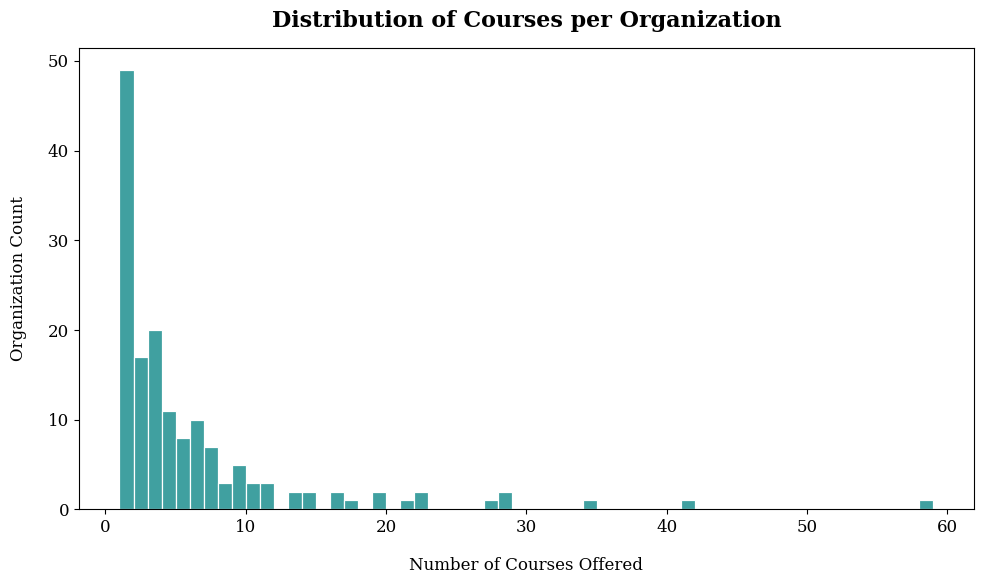



Unique organizations: 154
Organizations that offer multiple courses: 68.2%
Highest number of courses offered by one organization: 59


In [730]:
all_orgs = df.course_organization.value_counts()
all_orgs_count = all_orgs.count()
max_courses = all_orgs.max()
orgs_with_multiple_courses = all_orgs[all_orgs > 1]
count_orgs = orgs_with_multiple_courses.count()
pct_orgs = round(count_orgs / all_orgs_count * 100, 1)

plt.figure(figsize=(10, 6))
sns.histplot(
    data=all_orgs,
    color="teal",
    binwidth=1
)
plt.title(
    "Distribution of Courses per Organization"
)
plt.xlabel("Number of Courses Offered")
plt.ylabel("Organization Count")

plt.tight_layout()
plt.show()
print("\n")
print(f"Unique organizations: {all_orgs_count}")
print(
    f"Organizations that offer multiple "
    f"courses: {pct_orgs}%"
)
print(
    f"Highest number of courses offered "
    f"by one organization: {max_courses}"
)

### 3.2. Which organizations offer the most courses?

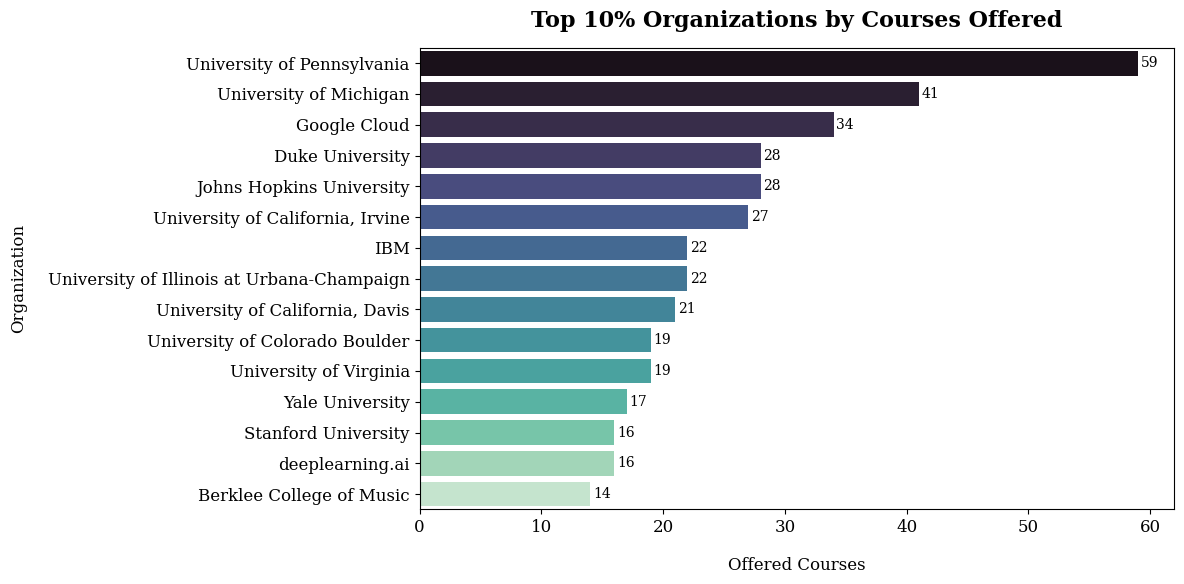

In [731]:
all_orgs = df.course_organization.value_counts()
unique_orgs = all_orgs.count()
top10_pct = int(round(unique_orgs * 0.10))
top_orgs = all_orgs.head(top10_pct)
top_orgs_df = top_orgs.reset_index(name="course_count")

plt.figure(figsize=(12, 6))
bar_plot = sns.barplot(
    data=top_orgs_df,
    y="course_organization",
    x="course_count",
    hue="course_organization",
    palette="mako"
)
for container in bar_plot.containers:
    bar_plot.bar_label(
        container,
        padding=2,
        fontsize=10
    )
plt.title(
    "Top 10% Organizations by Courses Offered"
)
plt.xlabel("Offered Courses")
plt.ylabel("Organization")

plt.tight_layout()
plt.show()

### 3.3. Which organizations have the highest total student enrollment?

In [742]:
all_orgs = (
    df.groupby("course_organization")["course_students_enrolled"]
    .sum()
    .sort_values(ascending=False)
)
unique_orgs = all_orgs.count()
top10_pct = int(round(unique_orgs * 0.10))
top_orgs = all_orgs.head(top10_pct)
top_10_df = top_orgs.reset_index(name="course_students_enrolled")

fig = px.bar(
    top_10_df,
    x="course_students_enrolled",
    y="course_organization",
    orientation='h',
    color="course_students_enrolled",
    color_continuous_scale="Deep",
    text="course_students_enrolled",
    text_auto=",.0f"
)

fig.update_layout(
    title={
        "text": "Top 10% Organizations by Total Student Enrollment",
        "font": dict(family="Arial", size=24, weight="bold"),
        "x": 0.5,
        "xanchor": "center"
    },
    xaxis_title=dict(
        text="Total Enrolled Students",
        font=dict(family="Arial", size=14)
    ),
    yaxis_title=dict(
        text="Organization",
        font=dict(family="Arial", size=14)
    ),
    yaxis=dict(categoryorder="total ascending"),
    height=600,
    paper_bgcolor="rgb(245, 245, 245)",
    plot_bgcolor="rgb(245, 245, 245)",
    coloraxis_showscale=False
)

fig.update_traces(
    textposition='outside'
)

fig.show()

### 3.4. How much of the market is occupied by top 10% organizations?

Here we are testing Hypothesis 1: Top 10% percent of organizations (by student enrollment) make up 50% or larger share of the market.


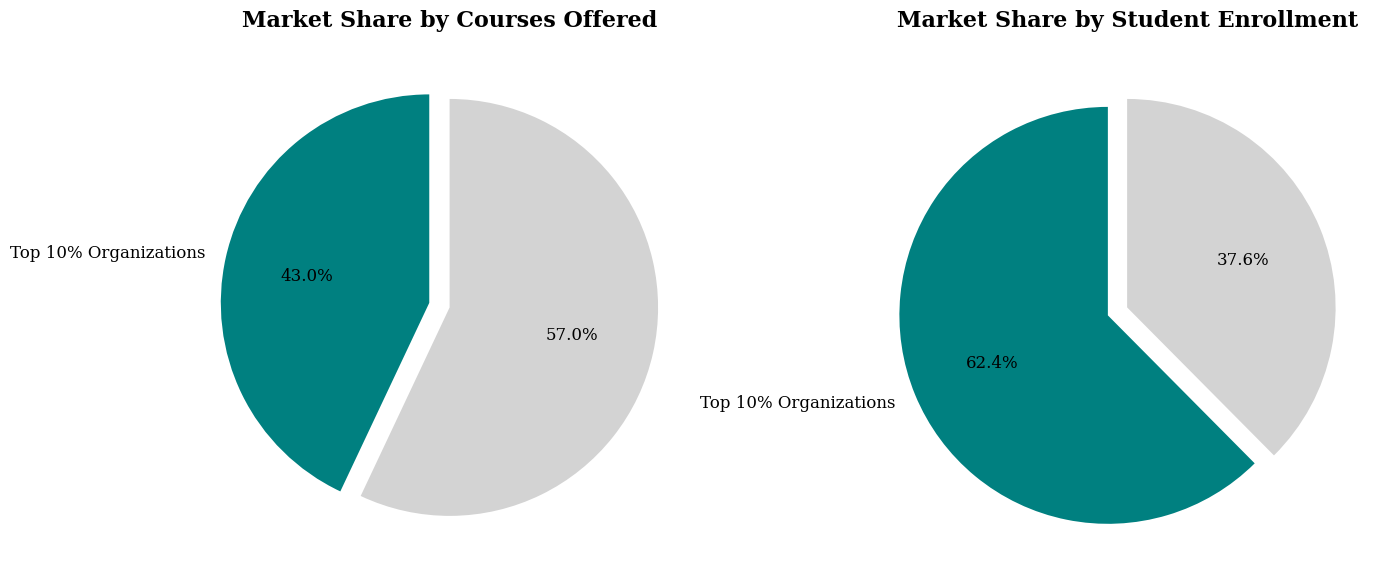

In [733]:
all_orgs_courses = df.course_organization.value_counts()
unique_orgs = all_orgs_courses.count()
top10_pct = int(round(unique_orgs * 0.10))
top_orgs_courses = all_orgs_courses.head(top10_pct)
top_orgs_sum_courses = top_orgs_courses.sum()
others_courses = len(df) - top_orgs_sum_courses
all_orgs_enrollment = (
    df.groupby("course_organization")["course_students_enrolled"]
    .sum()
    .sort_values(ascending=False)
)
top_orgs_enrollment = all_orgs_enrollment.head(top10_pct)
top_orgs_sum_enrollment = top_orgs_enrollment.sum()
total_students_in_courses = (
    df["course_students_enrolled"]
    .sum()
)
others_enrollment = total_students_in_courses - top_orgs_sum_enrollment
pie_courses_data = [top_orgs_sum_courses, others_courses]
pie_enrollment_data = [top_orgs_sum_enrollment, others_enrollment]


fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].pie(
    pie_courses_data,
    labels=["Top 10% Organizations", ""],
    autopct="%1.1f%%",
    colors=["teal", "lightgray"],
    explode=(0.1, 0),
    startangle=90
)
axes[0].set_title(
    "Market Share by Courses Offered"
)
axes[1].pie(
    pie_enrollment_data,
    labels=["Top 10% Organizations", ""],
    autopct="%1.1f%%",
    colors=["teal", "lightgray"],
    explode=(0.1, 0),
    startangle=90
)
axes[1].set_title(
    "Market Share by Student Enrollment"
)

plt.tight_layout()
plt.show()


Just as we have suspected, top 10% organizations make up the majority of Coursera online courses market, therefore, we can confirm Hypothesis 1.

One more question arises: how is student enrollment and number of courses by organization related?

I raise another hypothesis: there is a strong positive correlation (0.5 or higher) between average number of enrolled students in a course and the number of courses offered by the organization.



### 3.5. Is there a strong positive correlation between the number of courses offered by the organization and student enrollment?

Here we are testing Hypothesis 5: There is a strong positive correlation (0.5 or higher) between average number of enrolled students in a course and the number of courses offered by the organization.

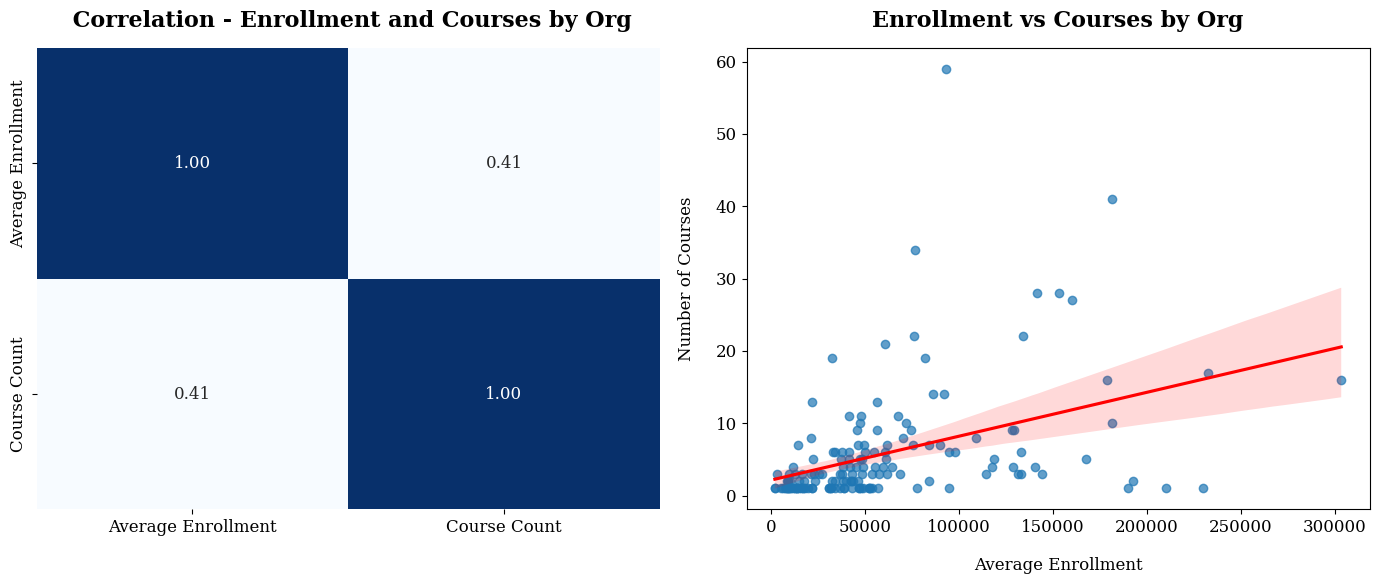

In [734]:
org_enrollment_df = (
    df.groupby("course_organization")["course_students_enrolled"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
    .set_index("course_organization")
)
org_courses_df = (
    df.course_organization
    .value_counts()
    .reset_index(name="course_count")
    .set_index("course_organization")
)
combined_df = org_enrollment_df.join(org_courses_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

corr = combined_df[["course_students_enrolled", "course_count"]].corr()
corr.index = ["Average Enrollment", "Course Count"]
corr.columns = ["Average Enrollment", "Course Count"]
sns.heatmap(
    corr,
    annot=True,
    cmap="Blues",
    fmt=".2f",
    cbar=False,
    ax=axes[0]
)
axes[0].set_title(
    " Correlation - Enrollment and Courses by Org"
)
sns.regplot(
    data=combined_df,
    x="course_students_enrolled",
    y="course_count",
    scatter_kws={"alpha": 0.7},
    line_kws={"color": "red"},
    ax=axes[1]
)
axes[1].set_title(
    "Enrollment vs Courses by Org"
)
axes[1].set_xlabel("Average Enrollment")
axes[1].set_ylabel("Number of Courses")

plt.tight_layout()
plt.show()

The correlation is 0.41, therefore, we have to reject the hypothesis.

Although we can confirm that there is indeed a positive correlation between the demand for courses and the supply of new courses.



### 3.6. Is there a positive correlation between course rating and course enrollment?

Here we are testing Hypothesis 2: Top 10% percent of organizations (by student enrollment) make up 50% or larger share of the market.

Because of the skewed distributions of both course rating and course enrollment data, Spearman correlation method was used.

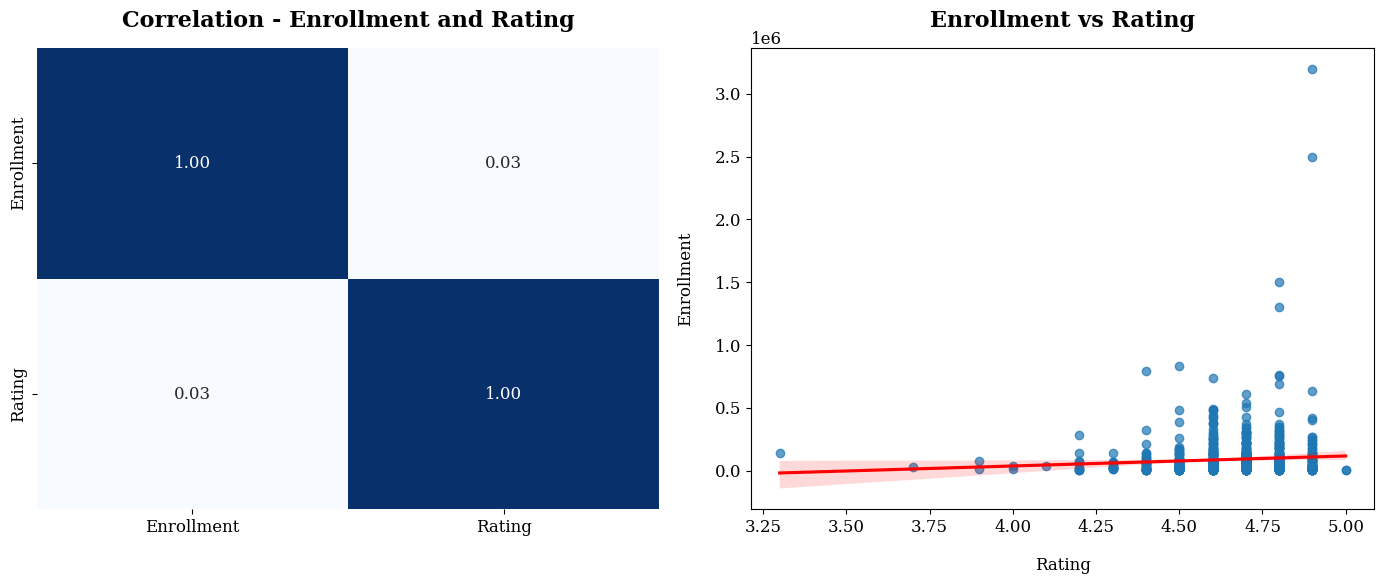

In [735]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

corr = (
    df[["course_students_enrolled", "course_rating"]]
    .corr(method="spearman")
)
corr.index = ["Enrollment", "Rating"]
corr.columns = ["Enrollment", "Rating"]
sns.heatmap(
    corr,
    annot=True,
    cmap="Blues",
    fmt=".2f",
    cbar=False,
    ax=axes[0]
)
axes[0].set_title(
    "Correlation - Enrollment and Rating"
)
sns.regplot(
    data=df,
    x="course_rating",
    y="course_students_enrolled",
    scatter_kws={"alpha": 0.7},
    line_kws={"color": "red"},
    ax=axes[1]
)
axes[1].set_title(
    "Enrollment vs Rating"
)
axes[1].set_xlabel("Rating")
axes[1].set_ylabel("Enrollment")

plt.tight_layout()
plt.show()


There is only a weak positive correlation between course ratings and enrollment, lower than was expected, therefore, we have to reject the hypothesis.

We can clearly see that the vast majority of Coursera courses are rated 4/5 or higher, which indicates a high industry standart, regardless of how popular courses are.

Here I raise another hypothesis: There is a positive correlation (0.25 or higher) between organization's average course rating and organization's average course enrollment.

### 3.7. Is there a positive correlation between organization's average course rating and average course enrollment?

Here we are testing Hypothesis 6: There is a positive correlation (0.25 or higher) between organization's average course rating and organization's average course enrollment.

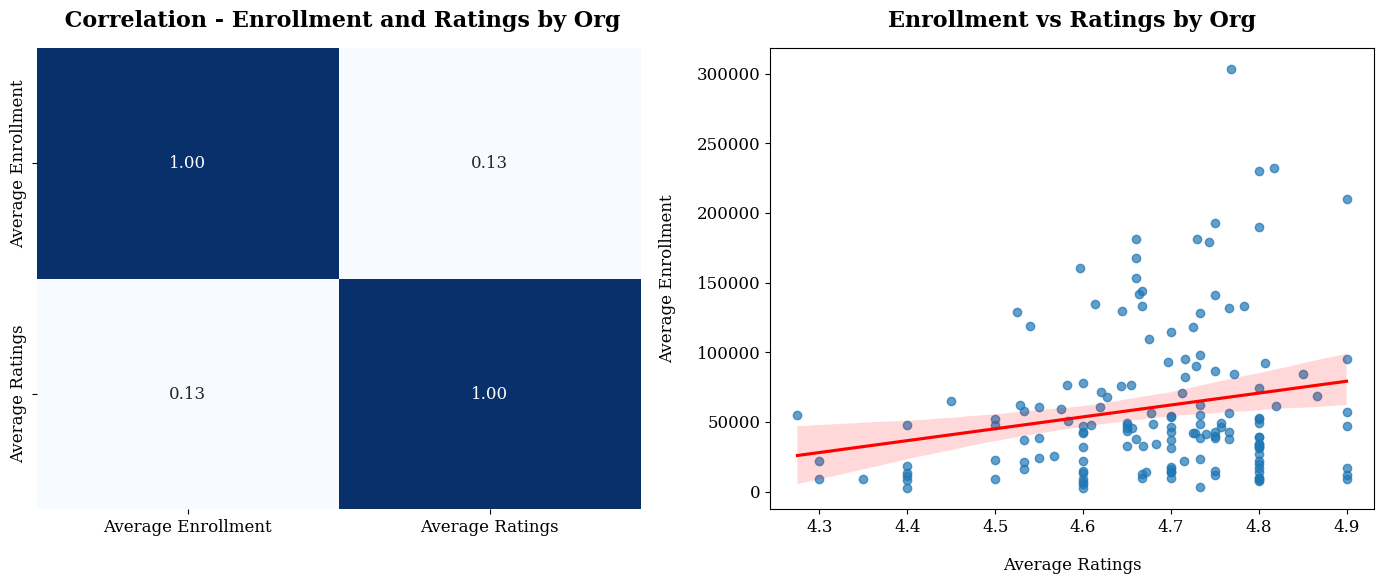

In [736]:
org_enrollment_df = (
    df.groupby("course_organization")["course_students_enrolled"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
    .set_index("course_organization")
)
org_ratings_df = (
    df.groupby("course_organization")["course_rating"]
    .mean()
    .sort_values(ascending=False)
    .reset_index(name="course_rating")
    .set_index("course_organization")
)
combined_df = org_enrollment_df.join(org_ratings_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

corr = (
    combined_df[["course_students_enrolled", "course_rating"]]
    .corr(method="spearman")
)
corr.index = ["Average Enrollment", "Average Ratings"]
corr.columns = ["Average Enrollment", "Average Ratings"]
sns.heatmap(
    corr,
    annot=True,
    cmap="Blues",
    fmt=".2f",
    cbar=False,
    ax=axes[0]
)
axes[0].set_title(
    " Correlation - Enrollment and Ratings by Org"
)
sns.regplot(
    data=combined_df,
    x="course_rating",
    y="course_students_enrolled",
    scatter_kws={"alpha": 0.7},
    line_kws={"color": "red"},
    ax=axes[1]
)
axes[1].set_title(
    "Enrollment vs Ratings by Org"
)
axes[1].set_xlabel("Average Ratings")
axes[1].set_ylabel("Average Enrollment")

plt.tight_layout()
plt.show()

Once again we have to reject our hypothesis, and even though it is stronger, we must conclude that ratings do not drive engagement, because of the already high industry standart.

### 3.8. How many courses are there by difficulty level?

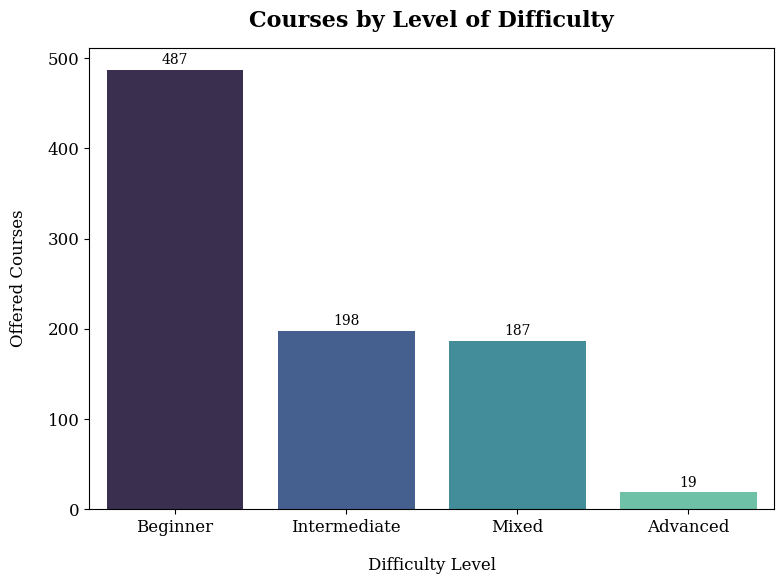

In [737]:
difficulty_count_df = (
    df["course_difficulty"]
    .value_counts()
    .reset_index(name="course_count")
)

plt.figure(figsize=(8, 6))
bar_plot = sns.barplot(
    data=difficulty_count_df,
    y="course_count",
    x="course_difficulty",
    hue="course_difficulty",
    palette="mako"
)

for container in bar_plot.containers:
    bar_plot.bar_label(
        container,
        padding=2,
        fontsize=10
    )

plt.title(
    "Courses by Level of Difficulty"
)
plt.xlabel("Difficulty Level")
plt.ylabel("Offered Courses")

plt.tight_layout()
plt.show()

### 3.9. How many courses are there by certificate type?

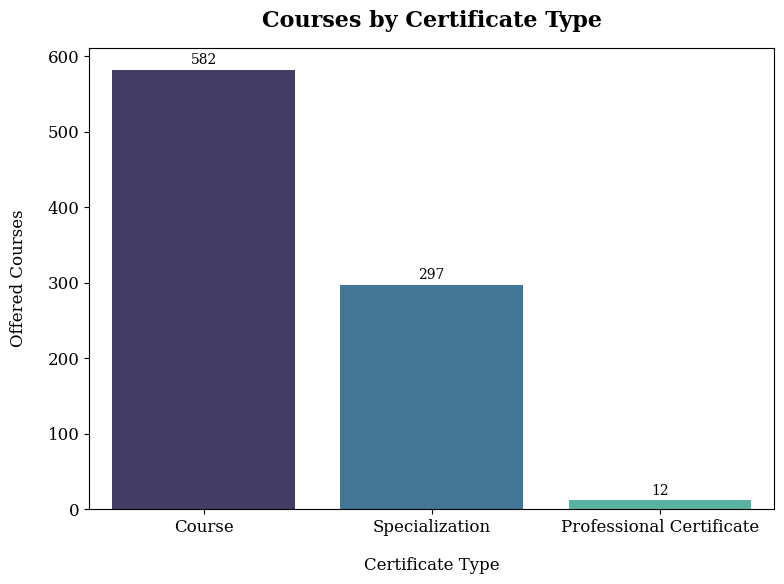

In [738]:
certificate_count_df = (
    df["course_certificate_type"]
    .value_counts()
    .reset_index(name="course_count")
    .set_index("course_certificate_type")
)
certificate_count_df.index = (
    certificate_count_df
    .index
    .str
    .title()
)

plt.figure(figsize=(8, 6))
bar_plot = sns.barplot(
    data=certificate_count_df,
    y="course_count",
    x="course_certificate_type",
    hue="course_certificate_type",
    palette="mako"
)

for container in bar_plot.containers:
    bar_plot.bar_label(
        container,
        padding=2,
        fontsize=10
    )

plt.title(
    "Courses by Certificate Type"
)
plt.xlabel("Certificate Type")
plt.ylabel("Offered Courses")

plt.tight_layout()
plt.show()

### 3.10. What is the market share of courses by difficulty level and certificate type?

Here we are testing two hypotheses.

Hypothesis 3: Courses with the lowest difficulty make up 50% or larger share of the market, while courses with the highest difficulty make up 10% or lower share of the market.

Hypothesis 4: Courses with the lowest-skill certificate types make up 50% of larger share of the market, while courses with higher-skill certificate types make up 10% or lower share of the market.

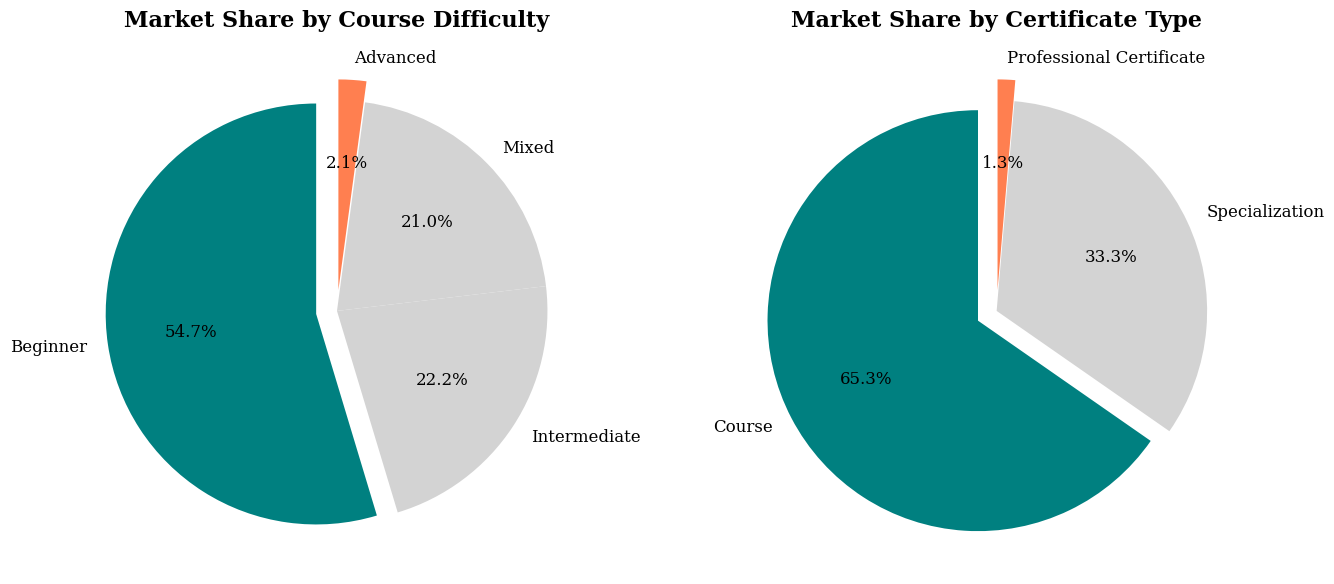

In [739]:
difficulty_counts = (
    df["course_difficulty"]
    .value_counts()
)
certificate_counts = (
    df["course_certificate_type"]
    .value_counts()
)
certificate_counts.index = (
    certificate_counts.index
    .str
    .title()
)


fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].pie(
    difficulty_counts,
    labels=["Beginner", "Intermediate", "Mixed", "Advanced"],
    autopct="%1.1f%%",
    colors=["teal", "lightgray", "lightgray", "coral"],
    explode=(0.1, 0, 0, 0.1),
    startangle=90
)
axes[0].set_title(
    "Market Share by Course Difficulty"
)
axes[1].pie(
    certificate_counts,
    labels=["Course", "Specialization", "Professional Certificate"],
    autopct="%1.1f%%",
    colors=["teal", "lightgray", "coral"],
    explode=(0.1, 0, 0.1),
    startangle=90
)
axes[1].set_title(
    "Market Share by Certificate Type"
)

plt.tight_layout()
plt.show()

We have to confirm both of our hypotheses.

Beginner level courses make up over 50% of the market while advanced level courses make up just 2.1% - much lower than the predicted 10%.

"Course" is the simplest certificate type on Coursera and it makes up almost two-thirds of the entire market, while "Professional Certificate", the highest level certificate out of three, makes up just 1.3%.

We can conclude that market supply is mostly simple, least difficult courses.

### 3.11. What is the course enrollment distribution by level of difficuly?

Note: I'm using logarithmic scales to display this boxplot for clearer visibility of the median and quartile limits.

In [740]:
fig = px.box(
    df,
    x="course_students_enrolled",
    y="course_difficulty",
    color="course_difficulty",
    points="all",
    labels={
        "course_students_enrolled": "Enrollment",
        "course_difficulty": "Difficulty"
    }
)
fig.update_traces(jitter=0.5)
fig.update_layout(
    title={
        "text": "Distribution by Difficulty",
        "font": dict(family="Arial", size=24, weight="bold"),
        "x": 0.5,
        "xanchor": "center"
    },
    xaxis=dict(
        title="Enrollment",
        gridcolor="white",
        gridwidth=3
    ),
    yaxis=dict(
        tickfont=dict(family="Arial", size=14)
    ),
    height=600,
    paper_bgcolor="rgb(240, 240, 240)",
    plot_bgcolor="rgb(240, 240, 240)",
    showlegend=False
)
fig.update_xaxes(type="log")
fig.show()


Mixed level courses have the highest enrollment on average, with a median value of 62k students in a course but the difference in not statistically significant because of the quartile overlap.

### 3.12. What is the course enrollment distribution by certificate type?

Note: I'm using logarithmic scales to display this boxplot for clearer visibility of the median and quartile limits.

In [741]:
df["course_certificate_type"] = (
    df["course_certificate_type"]
    .str
    .title()
)
fig = px.box(
    df,
    x="course_students_enrolled",
    y="course_certificate_type",
    color="course_certificate_type",
    points="all",
    labels={
        "course_students_enrolled": "Enrollment",
        "course_certificate_type": "Certificate Type"
    }
)
fig.update_traces(jitter=0.5)
fig.update_layout(
    title={
        "text": "Distribution by Certificate Type",
        "font": dict(family="Arial", size=24, weight="bold"),
        "x": 0.5,
        "xanchor": "center"
    },
    xaxis=dict(
        title="Enrollment",
        gridcolor="white",
        gridwidth=3
    ),
    yaxis=dict(
        tickfont=dict(family="Arial", size=14)
    ),
    height=600,
    paper_bgcolor="rgb(240, 240, 240)",
    plot_bgcolor="rgb(240, 240, 240)",
    showlegend=False
)
fig.update_xaxes(type="log")
fig.show()

Proffessional certificates have the highest median value out of all certificate types.

Regardless of this fact, there is very low supply of these courses and the difference from other certificate types is not statistically significant because the quartile overlap.

# 4. Results

1. Coursera online courses market is dominated by large organizations that can offer multiple courses. We have discovered that:

    - There are **154 unique organizations** offering 891 courses.
    - **68%** offer multiple courses.
    - Top 10% organizations offer **43%** of all courses.
    - Top 10% organizations get **62%** of all student enrollment.
2. There aren't any "strong" predictors of what drives course enrollment. We have discovered that:
    - There is a positive **0.41 correlation** between the number of courses offered by the organization and the average enrollment in a course.
    - There is a positive **0.13 correlation** between the organization's average course rating and average student enrollment.
    - There is a positive **0.03 correlation** between course rating and student enrollment variables.
    - A median course rating value of **4.7/5** indicates a high industry standart for online courses.
3. Majority of the courses offered in the market are of the lowest difficulty and offer the lowest-level certificates. We have discovered that:
    - **54%** of all Coursera courses are of beginner-level while **2%** - of advanced level.
    - **65%** of all Coursera courses offer lowest-level "Course" certificates while **1%** - highest-level "Professional Certificates".
    - Courses of **"Mixed"** difficulty have the highest median of student enrollment - **62k**. The difference is **not statistically significant**.
    - Courses that offer **"Proffesional Certificates"** have the highest median value of student enrollment - **145k**. The difference is **not statistically significant**.

---
---

In total, I've raised 6 hypotheses:
1.   Top 10% percent of organizations (by student enrollment) make up 50% or larger share of the market.
     - Confirmed
2.   Course student enrollment and course ratings are correlated. Expected correlation value - 0.25 or higher.
     - Rejected
3.   Courses with the lowest difficulty make up 50% or larger share of the market, while courses with the highest difficulty make up 10% or lower share of the market.
     - Confirmed
4.   Courses with the lowest-skill certificate types make up 50% of larger share of the market, while courses with higher-skill certificate types make up 10% or lower share of the market.
     - Confirmed
5. There is a strong positive correlation (0.5 or higher) between average number of enrolled students in a course and the number of courses offered by the organization.
    - Rejected
6. There is a positive correlation (0.25 or higher) between organization's average course rating and organization's average course enrollment.
    - Rejected.









# 5. Limitations
The scope of this analysis was limited by the lack of these values


*   Course creation date
*   Course language
*   Course topic/discipline
*   Course length
*   Course price

# 6. Recommendations


*   Sentiment analysis could be done to find out whether certain key phrases in course titles drive student enrollment

*   Analysis of just the top performing courses could be done to confirm/reject the findings of this analysis.



